In [1]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
df=pd.read_csv('/content/nn_ready.csv')

In [4]:
df.head()

,tempo,key,mode,danceability,energy,valence,acousticness,speechiness,liveness,loudness,duration_ms,popularity,is_hit
0,150.273,7,1,0.336,0.627,0.350,0.16400,0.0384,0.0708,-7.463,241107,88,1
1,150.035,9,0,0.542,0.900,0.395,0.07380,0.0546,0.1400,-4.586,242347,58,1
2,81.068,1,1,0.566,0.716,0.450,0.00691,0.0424,0.3700,-5.733,207481,90,1
3,144.015,0,1,0.737,0.802,0.682,0.46800,0.0878,0.0931,-4.771,172325,96,1
4,144.020,5,1,0.735,0.805,0.617,0.46800,0.0888,0.0940,-4.821,172325,72,1


In [6]:
X=df.drop('is_hit', axis=1)
y=df['is_hit']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [8]:
X_test_scaled

array([[-0.79345044, -1.15763914,  0.61119156, ...,  0.72099309,
        -0.4690848 ,  0.74138458],
       [-1.43844881,  1.37922732,  0.61119156, ...,  1.32561048,
         0.13215933, -0.32497939],
       [-0.20013095, -0.31201699,  0.61119156, ..., -0.82224959,
         1.28445337,  0.11411166],
       ...,
       [ 0.57408258,  0.25173112,  0.61119156, ...,  0.71824857,
        -0.02735056,  1.18047562],
       [-0.6587765 ,  0.53360517,  0.61119156, ..., -1.12359771,
        -0.20792691,  1.24320292],
       [-0.89745463, -0.03014294, -1.63614826, ...,  1.12992632,
        -0.38993602, -0.45043397]])

In [9]:
X_train_scaled

array([[ 0.96916204, -0.03014294, -1.63614826, ...,  1.03551489,
        -1.57354634,  0.74138458],
       [ 0.10875719,  0.25173112, -1.63614826, ..., -1.32833878,
        -0.98845631,  0.23956624],
       [-0.5418077 ,  0.81547922,  0.61119156, ...,  0.98968144,
        -0.03797826,  0.74138458],
       ...,
       [-1.76130713,  0.53360517,  0.61119156, ..., -0.02798598,
        -0.30891363,  0.23956624],
       [ 0.34998515,  1.09735327, -1.63614826, ..., -0.62464427,
         0.09941028, -0.1995248 ],
       [-0.06534927,  0.81547922,  0.61119156, ...,  0.54671617,
        -0.90825264,  1.55683938]])

In [13]:
model=Sequential()
model.add(Dense(12, activation='relu', input_dim=12))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 12)             │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407 (1.59 KB)

 Trainable params: 407 (1.59 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [19]:
history=model.fit(X_train_scaled, y_train, epochs=20, validation_split=0.2)

Epoch 1/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8029 - loss: 0.5158 - val_accuracy: 0.8164 - val_loss: 0.4691
Epoch 2/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8042 - loss: 0.4831 - val_accuracy: 0.8164 - val_loss: 0.4601
Epoch 3/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8042 - loss: 0.4756 - val_accuracy: 0.8164 - val_loss: 0.4557
Epoch 4/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8042 - loss: 0.4713 - val_accuracy: 0.8164 - val_loss: 0.4518
Epoch 5/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8042 - loss: 0.4679 - val_accuracy: 0.8164 - val_loss: 0.4513
Epoch 6/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8042 - loss: 0.4651 - val_accuracy: 0.8164 - val_loss: 0.4510
Epoch 7/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8042 - loss: 0.4629 - val_accuracy: 0.8164 - val_loss: 0.4492
Epoch 8/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8050 - loss: 0.4606 - val_accuracy: 0.

In [21]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.7799671592775042

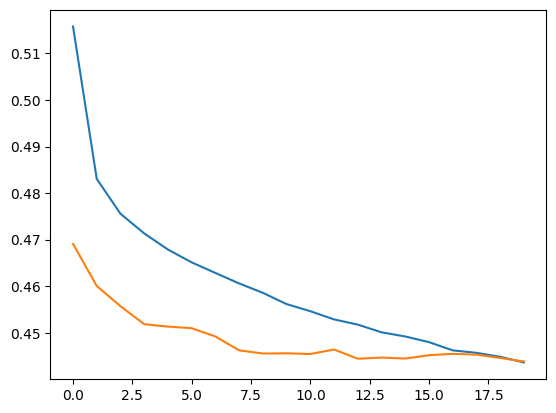

In [22]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

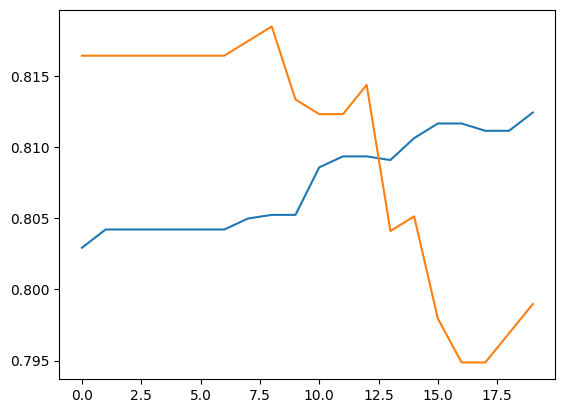

In [23]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])